In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils import data
import torchvision
from torchvision import transforms, models
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score
import copy
import time
import os
import numpy as np

import dataLoader
from data_augmentation import FrequencyBandZeroing

# Get GPU if possible, else get CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU! Using CPU only")

Using the GPU!


### Relevant Paths and Data Info

In [2]:
data_dir = '/workspace/data/cv_project'
models_dir = '/workspace/data/cv_project/models'

train_data = data_dir + '/grid_data_atten_big_train.h5'
val_data = data_dir + '/grid_data_atten_big_val.h5'
test_data = data_dir + '/grid_data_atten_big_test.h5'

exp_data = data_dir + '/wav_calls.h5'

# Maximum simulated range (to denormalize)
max_range = 35000

### Data Preparation Functions

Some functions to create the transforms for the dataloaders and then instantiate them.

In [3]:
def get_image_transforms():
    
    """
    Make dictionary of transforms for sets used for training/evaluation
    
    Returns
    -------
    transforms: dict, transforms for training/evaluation datasets
    """
    
    transform_eval = transforms.Compose([
        transforms.Normalize([0.4748, 0.5478, 0.5485], [0.1480, 0.1330, 0.1339]),
    ])

    transform_train = transforms.Compose([
        transforms.Normalize([0.4748, 0.5478, 0.5485], [0.1480, 0.1330, 0.1339]),
        FrequencyBandZeroing(max_freq_width=25)
    ])

    transform_dict = {'train': transform_train, 'eval': transform_eval}

    return transform_dict

def get_dataloaders(data_dir, batch_size, max_range, shuffle=True, transform=None):
    
    """
    Make dictionary of dataloaders for the train, validation, and test sets.
    
    Parameters
    ----------
    data_dir: str, directory that contains the data .h5 files
    batch_size: int, numbere of examples per batch
    shuffle: bool, whether or not to shuffle the training set
    transform: dict, dictionary of transforms with keys 'train' and 'eval'
    
    Returns
    -------
    dataloaders: dict, dictionary with data loaders for each dataset
    """
    
    # Get the similar parts of the train/validation/test file names
    name_base_train = "_".join((train_data.split('/')[-1].split('_')[:-1])) + "_"
    name_base_val = "_".join((val_data.split('/')[-1].split('_')[:-1])) + "_"
    name_base_test = "_".join((test_data.split('/')[-1].split('_')[:-1])) + "_"
    
    base_list = [name_base_train, name_base_val, name_base_test]
    
    if all(base == base_list[0] for base in base_list):
        # Transform dictionary
        data_transforms = {
            'train': transform['train'] if transform is not None else transform,
            'val': transform['eval'] if transform is not None else transform,
            'test': transform['eval'] if transform is not None else transform
        }

        # Create dataset
        datasets = {x: dataLoader.Gunshot(dir_path=os.path.join(data_dir, 'grid_data_atten_big_{}.h5'.format(x)), max_range=max_range, transform=data_transforms[x]) for x in data_transforms.keys()}

        # Make dataloaders
        dataloaders = {x: data.DataLoader(datasets[x], batch_size=batch_size, shuffle=False if x != 'train' else shuffle) for x in data_transforms.keys()}

        return dataloaders
    else:
        raise ValueError("According to their names, the data sets you are using to train appear to be inconsistent")

### Training Functions

Helper function to train/validate the model

In [4]:
def train(model, dataloaders, criterion, optimizer, num_epochs, max_range, save_dir=None, save_all_epochs=False):
    
    """
    Helper function with some features to train the model and save the most
    recent epoch with the lowest validation MSE.
    
    Parameters
    ----------
    model: nn.Module, model object.
    dataloaders: dict, dictionary containing at least the keys
                 'train', 'val', and 'test' which map to dataloaders
                 for these datasets.
    criterion: torch.nn.Loss, Loss function.
    optimizer: torch.optim, method of weight updating.
    num_epochs: int, number of epochs to train the model.
    max_range: float, maximum simulated range.
    save_dir: str, directory where models will be saved to. Make
              None to not write anything to disk.
    save_all_epochs: bool, whether to save the model weights for all
                     epochs, or just the best MSE weights.
    
    Returns
    -------
    model: nn.Module, model object with weights for best validation set MSE.
    val_mse_history: list, validation set MSE over all epochs
    train_mse_history: list, train set MSE over all epochs
    """
    
    # Time training
    since = time.time()
    
    # History vectors
    val_mse_history = []
    train_mse_history = []
    
    # Initialize best model
    best_model_wts = copy.deepcopy(model.state_dict())
    best_mse = float('inf')
    
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch + 1, num_epochs))
        print('-'*10)
        
        # Train + evaluate on validation data each epoch
        for phase in ['train', 'val']:
            if phase == 'train':
                # Put model in train mode
                model.train()
            else:
                # Put model in evaluation mode
                model.eval()
            
            # Keep track of loss, raw error, and number of calls
            running_loss = 0.0
            running_sq_error = 0.0
            running_call_num = 0
            running_correct = 0
            
            # Flip through data batches
            for inputs, r_labels, c_labels in tqdm(dataloaders[phase]):
                
                # Put data/labels on device
                inputs = inputs.to(device)
                r_labels = r_labels.to(device)
                c_labels = c_labels.to(device)
                
                # Zero out gradient for new batch
                optimizer.zero_grad()
                
                # Update weights
                with torch.set_grad_enabled(phase == 'train'):
                    
                    # Get model outputs and loss
                    outputs = model(inputs)
                    loss = criterion(outputs, r_labels, c_labels)
                    
                    # Backprop if we are training
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # Update running statistics -- sq_error only accumulated for examples with calls
                running_loss +=  loss.item() * inputs.size(0)
                running_sq_error += ((max_range*r_labels[c_labels.squeeze() == 1].squeeze() - max_range*outputs[c_labels.squeeze() == 1, 0].squeeze()) ** 2).sum().item()
                running_call_num += c_labels.sum().item()
                running_correct += ((outputs[:,1].squeeze() >= 0.5) == c_labels.squeeze()).sum().item()
                
            # Stats to display
            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_mse = running_sq_error / running_call_num
            epoch_acc = running_correct / len(dataloaders[phase].dataset)
            
            # Print epoch info
            print("{} Loss: {:.4f} -- MSE: {:.4f} m -- ACC: {:.4f}".format(phase, epoch_loss, epoch_mse/1000, epoch_acc))
            
            # Deep copy model
            if phase == 'val' and epoch_mse < best_mse:
                best_mse = epoch_mse
                best_model_wts = copy.deepcopy(model.state_dict())
            if phase == 'train':
                train_mse_history.append(epoch_mse)
            if phase == 'val':
                val_mse_history.append(epoch_mse)
            if phase == 'train' and save_all_epochs:
                torch.save(model.state_dict(), os.path.join(save_dir, 'weights_{}.pt'.format(epoch)))
            
        print()
        
    # Training done!
    time_elapsed = time.time() - since
    print('Training completed in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val MSE: {:.4f}'.format(best_mse/1000))
    
    # Save best model weights and load them into the model before returning
    torch.save(best_model_wts, os.path.join(save_dir, 'weights_best_val_mse.pt'))
    if not save_all_epochs:
        torch.save(model.state_dict(), os.path.join(save_dir, 'weights_last.pt'.format(epoch)))
    model.load_state_dict(best_model_wts)
    
    history = {'train_mse' : train_mse_history, 'val_mse' : val_mse_history}
    
    return model, history

Set up optimizer and loss.

In [5]:
def make_optimizer(model, learning_rate):
    
    """
    Create opimizer to train model.
    
    Returns
    -------
    optimizer: torch.optim, optimizer object.
    """
    
    # Make optimizer object
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    return optimizer

class SelectiveMSEAndClass(nn.Module):
    
    """
    Class for loss which adds binary cross entropy loss and MSE loss
    for range predictions. The MSE loss only penalizes incorrect range
    predictions for examples of class 1 (with a call in the spectrogram).
    """
    
    def __init__(self, alpha=1):
        super().__init__()
        self.MSE = nn.MSELoss()
        self.BCE = nn.BCELoss()
        self.alpha = alpha
        
    def forward(self, outputs, r_labels, c_labels):
        
        call_outs = outputs[c_labels.squeeze() == 1, 0]
        call_r_labels = r_labels[c_labels.squeeze() == 1]

        loss = self.alpha*self.MSE(call_outs.squeeze(), call_r_labels.squeeze()) + self.BCE(outputs[:,1].squeeze(), c_labels.squeeze())
        return loss

### Design Model

In [6]:
class CNNRNN(nn.Module):
    
    def __init__(self, input_size, hidden_size, num_layers, num_classes, lstm_dropout=None, fc_dropout=None):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.fc_dropout = fc_dropout
        
        # Get convolutional parts of resnet18
        resnet_full = models.resnet18(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet_full.children())[:-2])
        
        # Run random example through to get output shape
        sample = torch.randn((1, 3, input_size[0], input_size[1]))
        _, self.cnn_out_features, self.cnn_out_h, self.cnn_out_w = self.cnn(sample).shape
        
        self.lstm = nn.LSTM(input_size=3584, hidden_size=hidden_size, num_layers=num_layers, dropout=lstm_dropout, batch_first=True)
        self.fc = nn.Linear(in_features=hidden_size, out_features=num_classes)
        
        if fc_dropout is not None:
            self.dropout = nn.Dropout(p=fc_dropout)
        
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        
        # Get spatiotemporal features where "space" is frequency + magnitude
        out = self.cnn(x)
        
        # Make the out (batch, time_index, freq_features*num_feature_maps)
        out = out.permute(0, 2, 1, 3).contiguous()
        out = out.view(out.size(0), self.cnn_out_h, self.cnn_out_w*self.cnn_out_features)
        
        # Run through RNN and take output from last hidden/cell state
        h0 = torch.zeros(self.num_layers, out.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, out.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(out, (h0,c0))
        out = out[:,-1,:]
        
        # dropout
        if self.fc_dropout is not None:
            out = self.dropout(out)
        
        # Run through linear layer
        out = self.fc(out)
        
        # Run classification outputs through sigmoid
        out[:,1] = self.sigmoid(out[:,1])
        
        return out

### Train Model
Set hyperparameters.

In [7]:
# batch size for training
batch_size = 64

# shuffle training data
shuffle_dataset = True

# Number of epochs to train
epochs = 10

# Learning rate
learning_rate = 0.0001

# Whether or not to save weights after every epoch
save_all_epochs = False

# Hidden size
hidden_size = 200

# Number of RNN layers
num_layers = 2

# Number of classes
num_classes = 2

# LSTM dropout
lstm_dropout = 0.5

# fully connected dropout
fc_dropout = 0.5

# Set weight for range loss component
alpha = 100

# Directory to save weights to
save_dir = models_dir + '/huge_data_fine_tune'
os.makedirs(save_dir, exist_ok=True)

In [8]:
dl = get_dataloaders(data_dir=data_dir, 
                     batch_size=batch_size, 
                     max_range=max_range, 
                     shuffle=shuffle_dataset, 
                     transform=get_image_transforms())

model = CNNRNN(input_size=(224,224), 
               hidden_size=hidden_size, 
               num_layers=num_layers, 
               num_classes=num_classes, 
               lstm_dropout=lstm_dropout, 
               fc_dropout=fc_dropout).to(device)

In [10]:
optimizer = make_optimizer(model, learning_rate)
criterion = SelectiveMSEAndClass(alpha=alpha)

model, history = train(model=model, 
                       dataloaders=dl, 
                       criterion=criterion, 
                       optimizer=optimizer, 
                       num_epochs=epochs, 
                       max_range=max_range, 
                       save_dir=save_dir, 
                       save_all_epochs=False)

Epoch 1/10
----------


  0%|          | 0/1069 [00:00<?, ?it/s]

train Loss: 0.0676 -- MSE: 771.5502 m -- ACC: 0.9986


  0%|          | 0/167 [00:00<?, ?it/s]

val Loss: 0.0679 -- MSE: 752.2409 m -- ACC: 0.9982

Epoch 2/10
----------


...

val Loss: 0.0674 -- MSE: 711.7597 m -- ACC: 0.9974

Epoch 10/10
----------


  0%|          | 0/1069 [00:00<?, ?it/s]

train Loss: 0.0587 -- MSE: 692.3573 m -- ACC: 0.9995


  0%|          | 0/167 [00:00<?, ?it/s]

val Loss: 0.0717 -- MSE: 769.7499 m -- ACC: 0.9979

Training completed in 16m 27s
Best val MSE: 711.7597


### Evaluate Model

In [9]:
model.load_state_dict(torch.load(os.path.join(save_dir, 'weights_best_val_mse.pt')))

<All keys matched successfully>

In [11]:
def evaluate_model(model, dataloader, save_data=False):
    
    """
    Get predicted and ground truth values for range and class using a given model and dataloader
    
    Parameters
    ----------
    model: nn.Module, input model to be evaluated
    dataloader: torch.utils.data.DataLoader, dataloader for dataset to be used to evaluate model
    
    Returns
    -------
    ranges_p: array-like, predicted ranges
    ranges_t array-like, true classes
    class_p: array-like, predicted ranges
    class_t: array-like, true classes
    """
    
    # Put model in eval mode
    model.eval()
    
    # Store true labels
    ranges_t = []
    ranges_p = []
    class_t = []
    class_p = []
    
    # Store data
    X = []
    
    for inputs, r_labels, c_labels in tqdm(dataloader):

        inputs = inputs.to(device)
        r_labels = r_labels.to(device).squeeze()
        c_labels = c_labels.to(device).squeeze()

        with torch.set_grad_enabled(False):

            outputs = model(inputs)

            ranges_p += (outputs[:, 0]*max_range).detach().tolist()
            ranges_t += (r_labels*max_range).detach().tolist()
            class_p += (outputs[:,1] >= 0.5).tolist()
            class_t += c_labels.tolist()
            if save_data:
                X += inputs.tolist()

    ranges_p = np.asarray(ranges_p)
    ranges_t = np.asarray(ranges_t)
    class_p = np.asarray(class_p)
    class_t = np.asarray(class_t)
    X = np.asarray(X)
    
    return ranges_p, ranges_t, class_p, class_t, X
    
ranges_p, ranges_t, class_p, class_t, _ = evaluate_model(model, dl['test'], save_data=False)

p = precision_score(class_t, class_p)
r = recall_score(class_t, class_p)
print("Precision: {:.4f} \nRecall: {:.4f}".format(p, r))

  0%|          | 0/167 [00:00<?, ?it/s]

Precision: 0.9983 
Recall: 0.9977


#### Plot Range Predictions Against Ground Truth

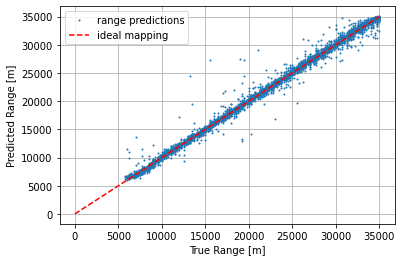

MSE: 428.75 m


In [12]:
def plot_true_pred(ranges_t, ranges_p, class_t, class_p, markersize=1):
    
    ranges_t = ranges_t[np.where((class_p >= 0.5) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p >= 0.5) & (class_t == 1))]
    
    plt.plot(ranges_t, ranges_p, 'o', markersize=markersize, label="range predictions")
    plt.plot([0, max_range], [0, max_range], '--r', label="ideal mapping")
    plt.grid()
    plt.legend()
    plt.xlabel("True Range [m]")
    plt.ylabel("Predicted Range [m]")
    plt.show()

    print("MSE: {:.2f} m".format(((ranges_t - ranges_p) ** 2).mean() / 1000))
    
plot_true_pred(ranges_t, ranges_p, class_t, class_p)

#### Plot Intra-Range Standard Deviation

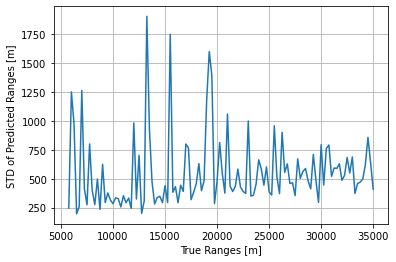

In [13]:
def plot_intra_range_std(ranges_t, ranges_p, class_t, class_p):
    
    ranges_t = ranges_t[np.where((class_p >= 0.5) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p >= 0.5) & (class_t == 1))]
    
    # Get standard deviation of each set of examples grouped by range
    unique_ranges = list(set(ranges_t))
    unique_ranges.sort()
    std_list = [np.std(ranges_p[ranges_t == r]) for r in unique_ranges]

    plt.plot(unique_ranges, std_list)
    plt.grid()
    plt.xlabel("True Ranges [m]")
    plt.ylabel("STD of Predicted Ranges [m]")
    plt.show()
    
plot_intra_range_std(ranges_t, ranges_p, class_t, class_p)

#### Plot Intra-Range Average Error

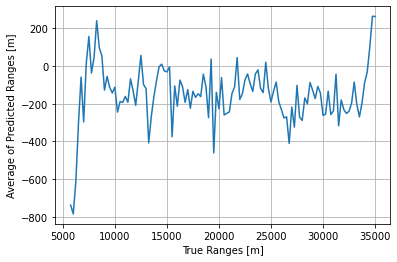

In [14]:
def plot_intra_range_avg_error(ranges_t, ranges_p, class_t, class_p):
    
    ranges_t = ranges_t[np.where((class_p >= 0.5) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p >= 0.5) & (class_t == 1))]
    
    # Get average error of each set of examples grouped by range
    unique_ranges = list(set(ranges_t))
    unique_ranges.sort()
    avg_err = [np.mean(r - ranges_p[ranges_t == r]) for r in unique_ranges]

    plt.plot(unique_ranges, avg_err)
    plt.grid()
    plt.xlabel("True Ranges [m]")
    plt.ylabel("Average of Predicted Ranges [m]")
    plt.show()
    
plot_intra_range_avg_error(ranges_t, ranges_p, class_t, class_p)

### Experimental Data

First let's create the dataloader and evaluate the model on the warped data.

In [21]:
warp_dataset = dataLoader.Warped(dir_path=exp_data, max_range=max_range, transform=get_image_transforms()['eval'])
warp_dl = {'test': data.DataLoader(warp_dataset, batch_size=10, shuffle=False)}

In [22]:
warp_ranges_p, warp_ranges_t, warp_class_p, warp_class_t, X = evaluate_model(model, warp_dl['test'])

  0%|          | 0/5 [00:00<?, ?it/s]

#### Plot Range Predictions Against Warped Ground Truth

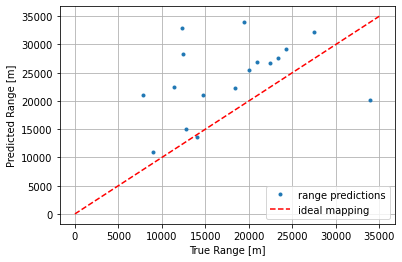

MSE: 93876.76 m


In [23]:
plot_true_pred(warp_ranges_t, warp_ranges_p, warp_class_t, warp_class_p, markersize=3)

#### Look at Highest Error Calls

In [26]:
warp_ranges_t = warp_ranges_t[np.where((warp_class_p >= 0.5) & (warp_class_t == 1))]
warp_ranges_p = warp_ranges_p[np.where((warp_class_p >= 0.5) & (warp_class_t == 1))]

In [27]:
a = np.abs(warp_ranges_p - warp_ranges_t)
inds = a.argsort()[::-1][:4]

In [28]:
a_err = a[inds]
X_err = X[inds,...]

IndexError: index 4 is out of bounds for axis 0 with size 0

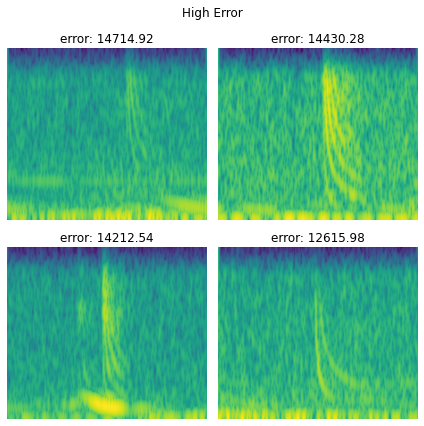

In [24]:
import plotter
plotter.plot_grid(X_err[:,[0],...], a_err, label_text="error", title="High Error", dim=(2,2), randomize=False)